In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

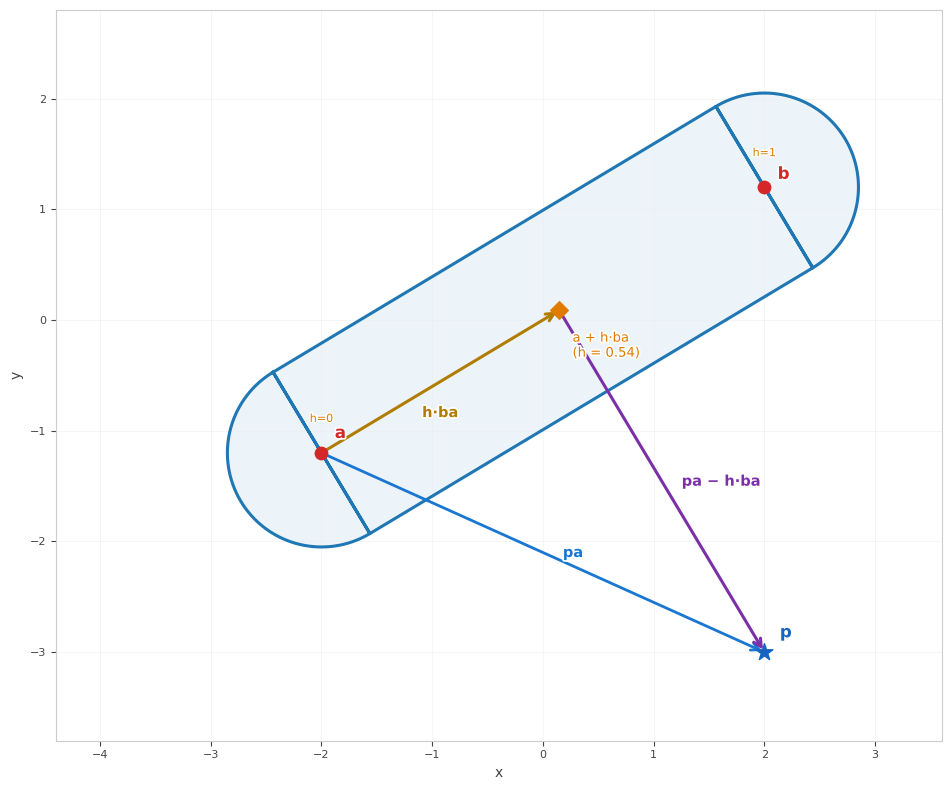

h = 0.537, closest = [0.14705882 0.08823529]


In [2]:
# ─── Palette ──────────────────────────────────────────────────────────────────
BG        = 'white'
CAPSULE   = '#1f77b4'
AXIS_CLR  = '#d62728'
PROJ_CLR  = '#e07b00'
QUERY_CLR = '#1565c0'
PA_CLR    = '#1976d2'
BA_CLR    = '#b07d00'
PERP_CLR  = '#7b2fa8'
DIM_CLR   = '#444444'

# ─── Capsule definition ───────────────────────────────────────────────────────
A = np.array([-2.0, -1.2])
B = np.array([ 2.0,  1.2])
R = 0.85

# Query point
P = np.array([2.0, -3.0])

# ─── SDF computation ─────────────────────────────────────────────────────────
pa = P - A
ba = B - A
h  = np.clip(np.dot(pa, ba) / np.dot(ba, ba), 0.0, 1.0)
closest      = A + h * ba
vec_to_p     = P - closest
dist_closest = np.linalg.norm(vec_to_p)
dir_to_p     = vec_to_p / dist_closest

# ─── Build capsule outline ────────────────────────────────────────────────────
def capsule_outline(a, b, r, res=400):
    axis      = b - a
    n         = axis / np.linalg.norm(axis)
    angle_deg = np.degrees(np.arctan2(n[1], n[0]))
    perp      = np.array([-n[1], n[0]])

    side1_a = a + perp * r
    side1_b = b + perp * r
    side2_b = b - perp * r
    side2_a = a - perp * r

    t_b = np.linspace(angle_deg - 90, angle_deg + 90, res // 2)
    sem_b_x = b[0] + r * np.cos(np.radians(t_b))
    sem_b_y = b[1] + r * np.sin(np.radians(t_b))

    t_a = np.linspace(angle_deg + 90, angle_deg + 270, res // 2)
    sem_a_x = a[0] + r * np.cos(np.radians(t_a))
    sem_a_y = a[1] + r * np.sin(np.radians(t_a))

    xs = ([side1_a[0], side1_b[0]]
          + list(sem_b_x)
          + [side2_b[0], side2_a[0]]
          + list(sem_a_x)
          + [side1_a[0]])
    ys = ([side1_a[1], side1_b[1]]
          + list(sem_b_y)
          + [side2_b[1], side2_a[1]]
          + list(sem_a_y)
          + [side1_a[1]])
    return np.array(xs), np.array(ys)

cap_x, cap_y = capsule_outline(A, B, R)

# ─── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8), facecolor=BG)
ax.set_facecolor(BG)
ax.set_aspect('equal')
ax.set_xlim(-4.4, 3.6)
ax.set_ylim(-3.8, 2.8)

for sp in ax.spines.values():
    sp.set_color('#cccccc')
ax.tick_params(colors=DIM_CLR, labelsize=8)
ax.grid(True, color='#eeeeee', linewidth=0.5, alpha=0.8, zorder=0)

# ── Capsule ───────────────────────────────────────────────────────────────────
ax.fill(cap_x, cap_y, color=CAPSULE, alpha=0.08, zorder=1)
ax.plot(cap_x, cap_y, color=CAPSULE, lw=2.2, alpha=1.0, zorder=2)

# ── Endpoints ─────────────────────────────────────────────────────────────────
ax.scatter(*A, color=AXIS_CLR, s=80, zorder=10)
ax.scatter(*B, color=AXIS_CLR, s=80, zorder=10)

# ── pa vector: a → p ──────────────────────────────────────────────────────────
ax.annotate('', xy=P, xytext=A,
            arrowprops=dict(arrowstyle='->', color=PA_CLR, lw=2.0,
                            mutation_scale=14))

# ── h·ba vector: a → closest ─────────────────────────────────────────────────
ax.annotate('', xy=closest, xytext=A,
            arrowprops=dict(arrowstyle='->', color=BA_CLR, lw=2.2,
                            mutation_scale=14))

# ── (pa − h·ba) vector: closest → p ──────────────────────────────────────────
ax.annotate('', xy=P, xytext=closest,
            arrowprops=dict(arrowstyle='->', color=PERP_CLR, lw=2.2,
                            mutation_scale=14))

# ── Closest point ─────────────────────────────────────────────────────────────
ax.scatter(*closest, color=PROJ_CLR, s=80, zorder=12, marker='D')

# ── Query point ───────────────────────────────────────────────────────────────
ax.scatter(*P, color=QUERY_CLR, s=160, zorder=12, marker='*')

# ── Labels ────────────────────────────────────────────────────────────────────
def lbl(pos, txt, color, dx=0.08, dy=0.08, fs=10.5, fw='bold', ha='left'):
    ax.text(pos[0]+dx, pos[1]+dy, txt, color=color, fontsize=fs,
            fontweight=fw, ha=ha, va='center',
            path_effects=[pe.withStroke(linewidth=2.5, foreground=BG)])

lbl(A, 'a', AXIS_CLR,  dx= 0.12, dy= 0.18, fs=12)
lbl(B, 'b', AXIS_CLR,  dx= 0.12, dy= 0.12, fs=12)
lbl(P, 'p', QUERY_CLR, dx=0.14, dy=0.18, fs=12)

lbl(closest, f'a + h·ba\n(h = {h:.2f})', PROJ_CLR,
    dx=0.12, dy=-0.32, fs=9.5, fw='normal')

pa_mid = A + pa * 0.5
lbl(pa_mid, 'pa', PA_CLR, dx=0.18, dy=0.0, fs=10.5, ha='left')

hba_mid = A + h * ba * 0.5
lbl(hba_mid, 'h·ba', BA_CLR, dx=0.0, dy=-0.28, fs=10.5, ha='center')

perp_mid = closest + vec_to_p * 0.5
lbl(perp_mid, 'pa − h·ba', PERP_CLR, dx=0.18, dy=0.0, fs=10.5, ha='left')

ax.text(A[0], A[1]+0.28, 'h=0', color=PROJ_CLR, fontsize=8,
        ha='center', path_effects=[pe.withStroke(linewidth=2, foreground=BG)])
ax.text(B[0], B[1]+0.28, 'h=1', color=PROJ_CLR, fontsize=8,
        ha='center', path_effects=[pe.withStroke(linewidth=2, foreground=BG)])

ax.set_xlabel('x', color=DIM_CLR)
ax.set_ylabel('y', color=DIM_CLR)

plt.tight_layout()
plt.show()
print(f"h = {h:.3f}, closest = {closest}")

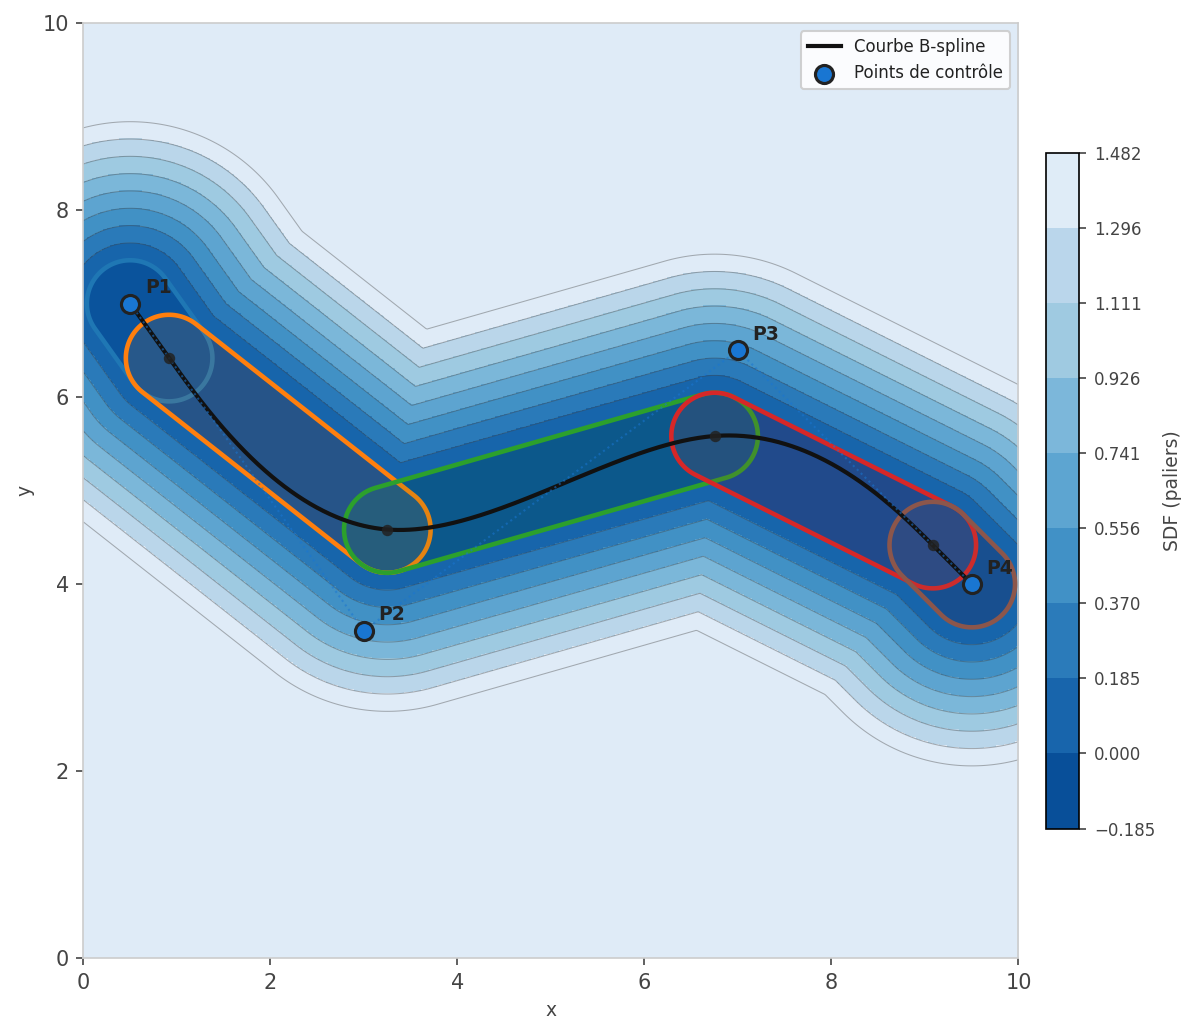

done


In [3]:
def bspline_pos(p0, p1, p2, p3, t):
    t2, t3 = t*t, t*t*t
    b0 = (-t3 + 3*t2 - 3*t + 1) / 6.0
    b1 = ( 3*t3 - 6*t2      + 4) / 6.0
    b2 = (-3*t3 + 3*t2 + 3*t + 1) / 6.0
    b3 =   t3                      / 6.0
    return p0*b0 + p1*b1 + p2*b2 + p3*b3

P = np.array([[0.5, 7.0],
              [3.0, 3.5],
              [7.0, 6.5],
              [9.5, 4.0]])

# B-spline bridée : répéter les extrémités 3× pour forcer le passage par P[0] et P[-1]
clamped = np.array([P[0], P[0], P[0], P[1], P[2], P[3], P[3], P[3]])
n_segs  = len(clamped) - 3  # 5 segments

def eval_clamped(pts, t_global):
    """t_global ∈ [0, n_segs]"""
    i   = int(np.clip(t_global, 0, n_segs - 1))
    t   = t_global - i
    return bspline_pos(pts[i], pts[i+1], pts[i+2], pts[i+3], t)

T_fine = np.linspace(0, n_segs, 800)
curve  = np.array([eval_clamped(clamped, t) for t in T_fine])

N_CAPS = 5
T_caps = np.linspace(0, n_segs, N_CAPS + 1)
caps   = np.array([eval_clamped(clamped, t) for t in T_caps])

seg_lengths = np.linalg.norm(np.diff(caps, axis=0), axis=1)
RADIUS = float(np.mean(seg_lengths) * 0.22)

# --- SDF ----------------------------------------------------------------
RES = 700
x1d = np.linspace(0, 10, RES)
y1d = np.linspace(0, 10, RES)
XX, YY = np.meshgrid(x1d, y1d)
pts = np.stack([XX.ravel(), YY.ravel()], axis=1)

def capsule_sdf_batch(q, A, B):
    AB   = B - A
    len2 = float(np.dot(AB, AB))
    if len2 < 1e-12:
        return np.linalg.norm(q - A, axis=1)
    t       = np.clip(((q - A) @ AB) / len2, 0.0, 1.0)
    closest = A + t[:, None] * AB
    return np.linalg.norm(q - closest, axis=1)

dist = np.full(len(pts), np.inf)
for i in range(N_CAPS):
    dist = np.minimum(dist, capsule_sdf_batch(pts, caps[i], caps[i+1]))

sdf_img = (dist - RADIUS).reshape(RES, RES)

STEP      = RADIUS * 0.4
MAX_BANDS = 8
levels    = np.arange(-1, MAX_BANDS + 1) * STEP
n_colors  = MAX_BANDS + 2
blues     = plt.cm.Blues(np.linspace(0.88, 0.12, n_colors))
cmap      = plt.cm.colors.ListedColormap(blues)
norm      = BoundaryNorm(levels, ncolors=n_colors, clip=True)

def capsule_patch(A, B, r, n_arc=60, **kwargs):
    AB   = B - A
    tang = AB / np.linalg.norm(AB)
    perp = np.array([-tang[1], tang[0]])
    angles_B = np.linspace(-np.pi/2,  np.pi/2,  n_arc)
    angles_A = np.linspace( np.pi/2,  3*np.pi/2, n_arc)
    arc_B = B + r * (np.outer(np.cos(angles_B), tang) +
                     np.outer(np.sin(angles_B), perp))
    arc_A = A + r * (np.outer(np.cos(angles_A), tang) +
                     np.outer(np.sin(angles_A), perp))
    verts = np.vstack([arc_B, arc_A, arc_B[0:1]])
    codes = ([Path.MOVETO] +
             [Path.LINETO] * (len(arc_B) - 1) +
             [Path.LINETO] * len(arc_A) +
             [Path.CLOSEPOLY])
    return PathPatch(Path(verts, codes), **kwargs)

# --- plot ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7), dpi=150)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.imshow(sdf_img, origin='lower', extent=[0, 10, 0, 10],
          cmap=cmap, norm=norm, interpolation='nearest', zorder=0)

visible = levels[levels >= -STEP * 0.4]
ax.contour(XX, YY, sdf_img, levels=visible,
           colors='#444444', linewidths=0.5, alpha=0.4, zorder=1)

cap_colors = plt.cm.tab10(np.linspace(0, 0.5, N_CAPS))
for i in range(N_CAPS):
    ax.add_patch(capsule_patch(caps[i], caps[i+1], RADIUS,
                               facecolor=(*cap_colors[i][:3], 0.12),
                               edgecolor=(*cap_colors[i][:3], 1.0),
                               linewidth=2.2, linestyle='-', zorder=3))

ax.scatter(caps[:, 0], caps[:, 1],
           s=30, color='#222222', zorder=5, linewidths=0, alpha=0.85)

ax.plot(curve[:, 0], curve[:, 1],
        color='#111111', lw=2.0, zorder=4, label='Courbe B-spline')

ax.plot(P[:, 0], P[:, 1],
        color='#1976d2', lw=1.0, linestyle=':', alpha=0.55, zorder=4)

ax.scatter(P[:, 0], P[:, 1],
           s=75, color='#1976d2', edgecolors='#222222',
           linewidths=1.5, zorder=7, label='Points de contrôle')
for i, p in enumerate(P):
    ax.annotate(f'P{i+1}', p, xytext=(7, 5), textcoords='offset points',
                fontsize=9, color='#222222', fontweight='bold', zorder=8)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('SDF (paliers)', fontsize=9, color='#444')
cbar.ax.yaxis.set_tick_params(color='#444', labelcolor='#444', labelsize=8)

ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.set_xlabel('x', fontsize=9, color='#444')
ax.set_ylabel('y', fontsize=9, color='#444')
ax.tick_params(colors='#444')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')
ax.legend(fontsize=8, loc='upper right',
          framealpha=0.9, facecolor='white', edgecolor='#cccccc', labelcolor='#222222')

plt.tight_layout()
plt.show()
print("done")

# 🎨 Analyse du Bruit de Raytrace
### Métriques de convergence pour une image rendue sans référence
---
Ce notebook analyse le bruit présent dans une image raytraced (sans image de référence) à l'aide de :
- La **variance locale** (carte de bruit par fenêtre glissante)
- La **détection de fireflies** (pixels aberrants très lumineux)
- Le **rapport signal/bruit (SNR)**
- Les **statistiques par canal R/G/B**


## 1. Importation des bibliothèques

In [4]:
import numpy as np
from PIL import Image
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from pathlib import Path

# Style sombre pour les graphiques
plt.rcParams.update({
    'figure.facecolor': '#0e0e0e',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#444444',
    'axes.labelcolor':  '#aaaaaa',
    'xtick.color':      '#aaaaaa',
    'ytick.color':      '#aaaaaa',
    'text.color':       '#ffffff',
    'grid.color':       '#333333',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})
print("✅ Bibliothèques chargées.")


✅ Bibliothèques chargées.


## 2. Chargement de l'image

Image chargée : profile16spp1000.png
Dimensions    : 1000 × 1000 pixels
Canaux        : 3 (RVB)


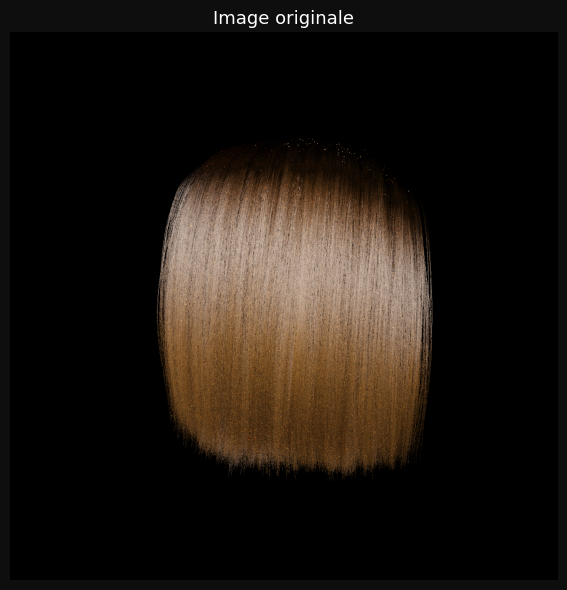

In [5]:
# ⚙️ Modifiez ce chemin selon votre image
CHEMIN_IMAGE = "profile16spp1000.png"

img = Image.open(CHEMIN_IMAGE).convert("RGB")
arr = np.array(img, dtype=np.float32)
H, W, C = arr.shape

print(f"Image chargée : {Path(CHEMIN_IMAGE).name}")
print(f"Dimensions    : {W} × {H} pixels")
print(f"Canaux        : {C} (RVB)")

# Affichage rapide
fig, ax = plt.subplots(figsize=(6, 6), facecolor='#0e0e0e')
ax.imshow(arr.astype(np.uint8))
ax.set_title("Image originale", color='white', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Masque de la région d'intérêt
On exclut le fond noir (luminance < 8) pour ne mesurer le bruit que dans la zone rendue.


Pixels dans la région rendue : 252,319
Pourcentage de l'image       : 25.2 %


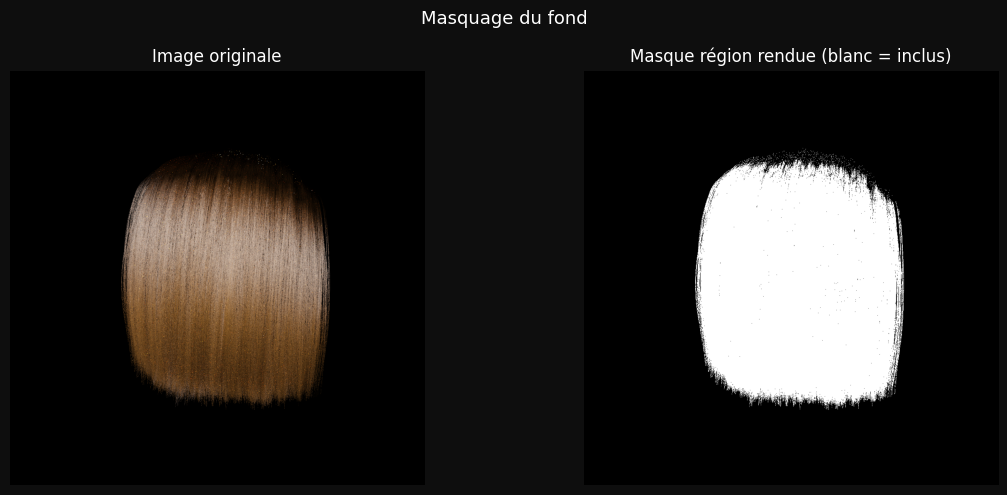

In [6]:
luminance = arr.mean(axis=2)
SEUIL_FOND = 8  # pixels sous ce seuil = fond noir
masque = luminance > SEUIL_FOND

nb_pixels_hair = masque.sum()
print(f"Pixels dans la région rendue : {nb_pixels_hair:,}")
print(f"Pourcentage de l'image       : {100 * nb_pixels_hair / (H * W):.1f} %")

# Visualisation du masque
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='#0e0e0e')
axes[0].imshow(arr.astype(np.uint8))
axes[0].set_title("Image originale", color='white')
axes[0].axis('off')
axes[1].imshow(masque, cmap='gray')
axes[1].set_title("Masque région rendue (blanc = inclus)", color='white')
axes[1].axis('off')
plt.suptitle("Masquage du fond", color='white', fontsize=13)
plt.tight_layout()
plt.show()


## 4. Carte de bruit — Variance locale
On calcule l'écart-type local dans une fenêtre glissante pour chaque canal, puis on fait la moyenne.
Un écart-type élevé dans une zone qui devrait être lisse = bruit de raytrace.


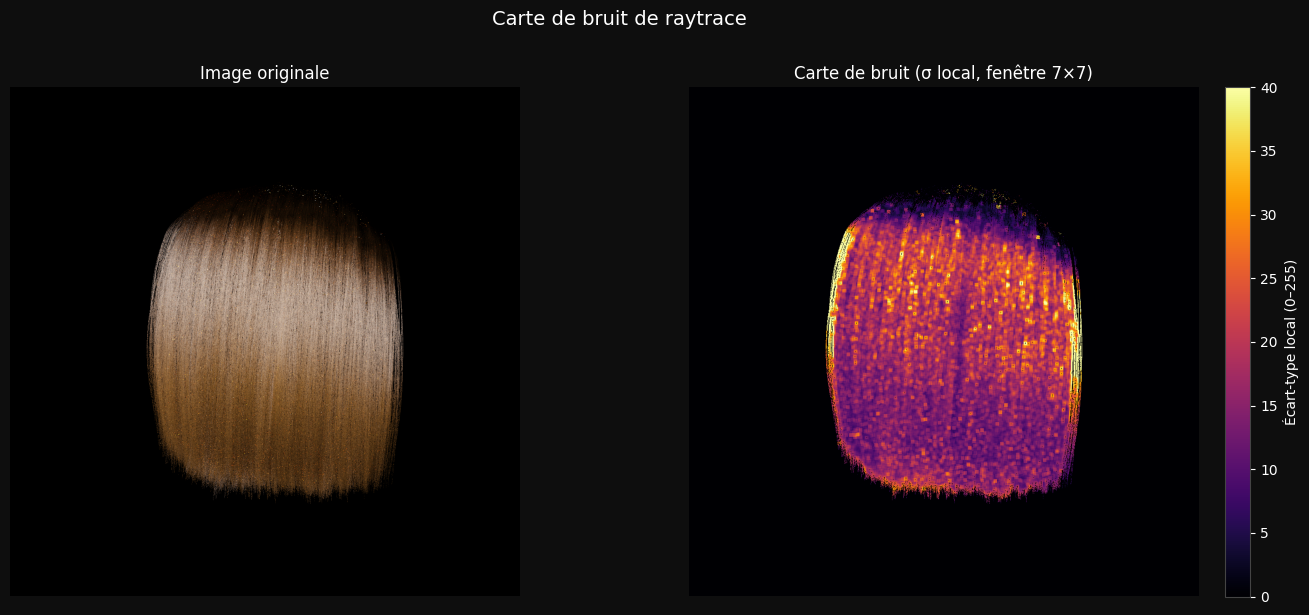

In [7]:
TAILLE_FENETRE = 7  # taille de la fenêtre glissante (pixels)

def variance_locale(canal, taille):
    """Calcule la variance locale par fenêtre glissante."""
    moyenne    = uniform_filter(canal, size=taille)
    moy_carree = uniform_filter(canal**2, size=taille)
    return np.clip(moy_carree - moyenne**2, 0, None)

# Calcul sur les 3 canaux
cartes_var = [variance_locale(arr[:,:,c], TAILLE_FENETRE) for c in range(3)]
carte_var  = np.stack(cartes_var, axis=2).mean(axis=2)
carte_std  = np.sqrt(carte_var)

# Masquer le fond
carte_std_masquee = np.where(masque, carte_std, 0)

# Affichage
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#0e0e0e')

im0 = axes[0].imshow(arr.astype(np.uint8))
axes[0].set_title("Image originale", color='white', fontsize=12)
axes[0].axis('off')

im1 = axes[1].imshow(carte_std_masquee, cmap='inferno', vmin=0, vmax=40)
axes[1].set_title("Carte de bruit (σ local, fenêtre 7×7)", color='white', fontsize=12)
axes[1].axis('off')
cb = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cb.set_label("Écart-type local (0–255)", color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')

plt.suptitle("Carte de bruit de raytrace", color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 5. Statistiques globales de bruit

  RÉSUMÉ DES MÉTRIQUES DE BRUIT
  Bruit moyen  (σ)     : 17.76 / 255  (7.0 %)
  Bruit médian (σ)     : 16.79 / 255
  90e percentile       : 25.64 / 255
  Bruit max            : 68.40 / 255
  Luminance moyenne    : 92.24 / 255
  SNR                  : 5.2


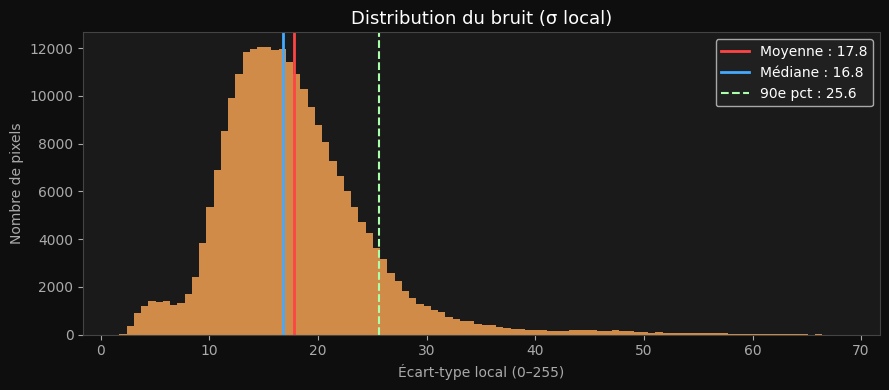

In [8]:
bruit_hair = carte_std[masque]
lum_hair   = luminance[masque]
snr        = lum_hair.mean() / (bruit_hair.mean() + 1e-6)

print("=" * 45)
print("  RÉSUMÉ DES MÉTRIQUES DE BRUIT")
print("=" * 45)
print(f"  Bruit moyen  (σ)     : {bruit_hair.mean():.2f} / 255  ({100*bruit_hair.mean()/255:.1f} %)")
print(f"  Bruit médian (σ)     : {np.median(bruit_hair):.2f} / 255")
print(f"  90e percentile       : {np.percentile(bruit_hair, 90):.2f} / 255")
print(f"  Bruit max            : {bruit_hair.max():.2f} / 255")
print(f"  Luminance moyenne    : {lum_hair.mean():.2f} / 255")
print(f"  SNR                  : {snr:.1f}")
print("=" * 45)

# Histogramme de distribution du bruit
fig, ax = plt.subplots(figsize=(9, 4), facecolor='#0e0e0e')
ax.hist(bruit_hair, bins=100, color='#f0a050', edgecolor='none', alpha=0.85)
ax.axvline(bruit_hair.mean(),       color='#ff4444', lw=2, label=f"Moyenne : {bruit_hair.mean():.1f}")
ax.axvline(np.median(bruit_hair),   color='#44aaff', lw=2, label=f"Médiane : {np.median(bruit_hair):.1f}")
ax.axvline(np.percentile(bruit_hair, 90), color='#aaffaa', lw=1.5, linestyle='--',
           label=f"90e pct : {np.percentile(bruit_hair,90):.1f}")
ax.set_title("Distribution du bruit (σ local)", color='white', fontsize=13)
ax.set_xlabel("Écart-type local (0–255)", color='#aaaaaa')
ax.set_ylabel("Nombre de pixels", color='#aaaaaa')
ax.legend(facecolor='#222', labelcolor='white', fontsize=10)
plt.tight_layout()
plt.show()


## 6. Détection des Fireflies
Les fireflies sont des pixels anormalement brillants par rapport à leur voisinage local.
On les détecte avec un **score Z** : `z = (pixel - moyenne_locale) / σ_locale`.
Un score Z > 4 indique un outlier statistique (firefly probable).


/tmp/ipykernel_189358/585112214.py:7: RuntimeWarning: invalid value encountered in divide
  score_z = np.where(std_locale > 1, (luminance - moy_locale) / std_locale, 0)


Seuil Z            : 4.0
Fireflies détectés : 696 pixels
Proportion         : 0.276 % des pixels rendus


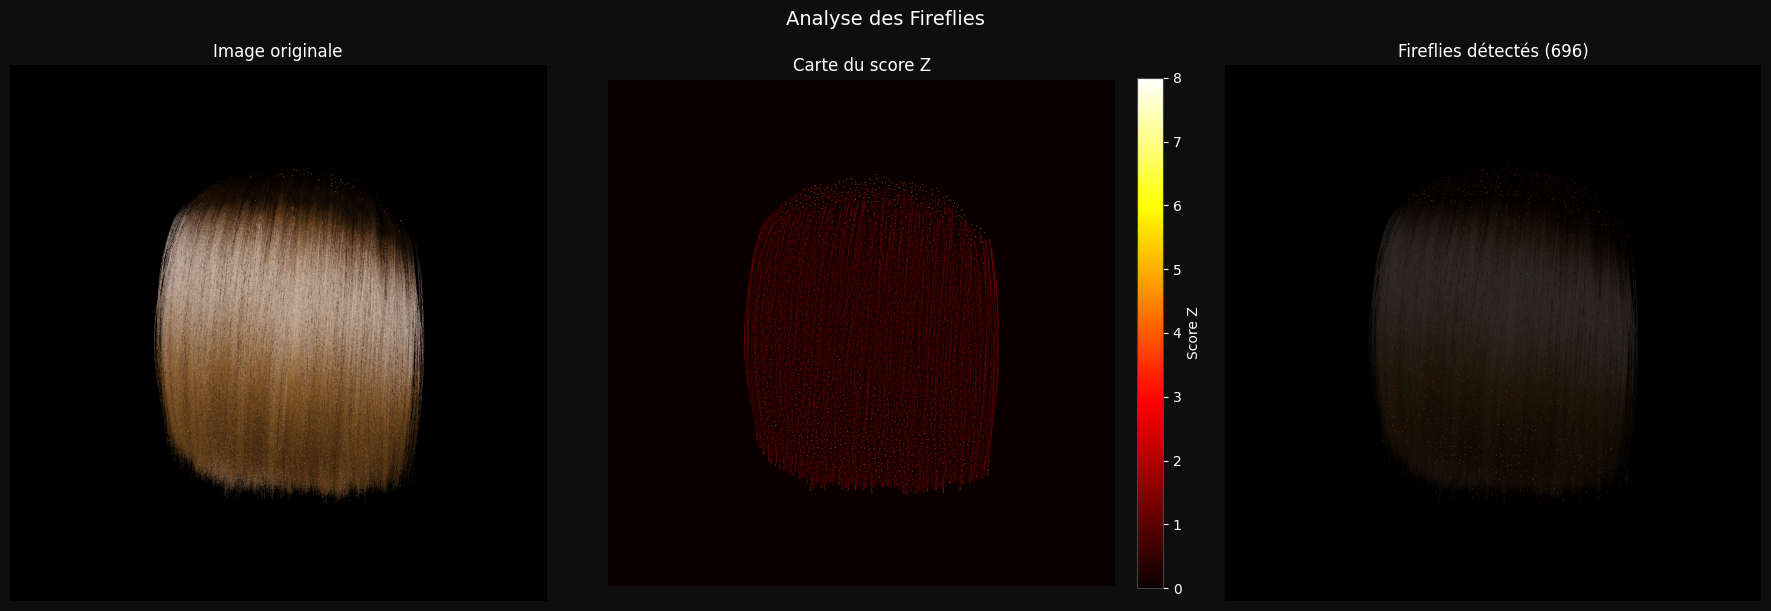

In [9]:
SEUIL_Z = 4.0  # seuil de détection des fireflies

moy_locale = uniform_filter(luminance, size=11)
var_locale  = np.clip(uniform_filter(luminance**2, size=11) - moy_locale**2, 0, None)
std_locale  = np.sqrt(var_locale)

score_z = np.where(std_locale > 1, (luminance - moy_locale) / std_locale, 0)
fireflies = (score_z > SEUIL_Z) & masque

print(f"Seuil Z            : {SEUIL_Z}")
print(f"Fireflies détectés : {fireflies.sum():,} pixels")
print(f"Proportion         : {100 * fireflies.sum() / masque.sum():.3f} % des pixels rendus")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0e0e0e')

axes[0].imshow(arr.astype(np.uint8))
axes[0].set_title("Image originale", color='white', fontsize=12)
axes[0].axis('off')

# Carte du score Z
z_display = np.where(masque, np.clip(score_z, 0, 8), 0)
im_z = axes[1].imshow(z_display, cmap='hot', vmin=0, vmax=8)
axes[1].set_title("Carte du score Z", color='white', fontsize=12)
axes[1].axis('off')
cb_z = plt.colorbar(im_z, ax=axes[1], fraction=0.046, pad=0.04)
cb_z.set_label("Score Z", color='white')
cb_z.ax.yaxis.set_tick_params(color='white')
plt.setp(cb_z.ax.yaxis.get_ticklabels(), color='white')

# Fireflies surlignés en rouge
img_ff = (arr * 0.25).astype(np.uint8).copy()
img_ff[fireflies] = [255, 60, 60]
axes[2].imshow(img_ff)
axes[2].set_title(f"Fireflies détectés ({fireflies.sum()})", color='white', fontsize=12)
axes[2].axis('off')

plt.suptitle("Analyse des Fireflies", color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 7. Analyse par canal RVB

Rouge (R)     σ moyen=21.13  médiane=19.93  90e pct=29.55
Vert (V)      σ moyen=17.04  médiane=16.13  90e pct=25.47
Bleu (B)      σ moyen=13.69  médiane=13.03  90e pct=22.96


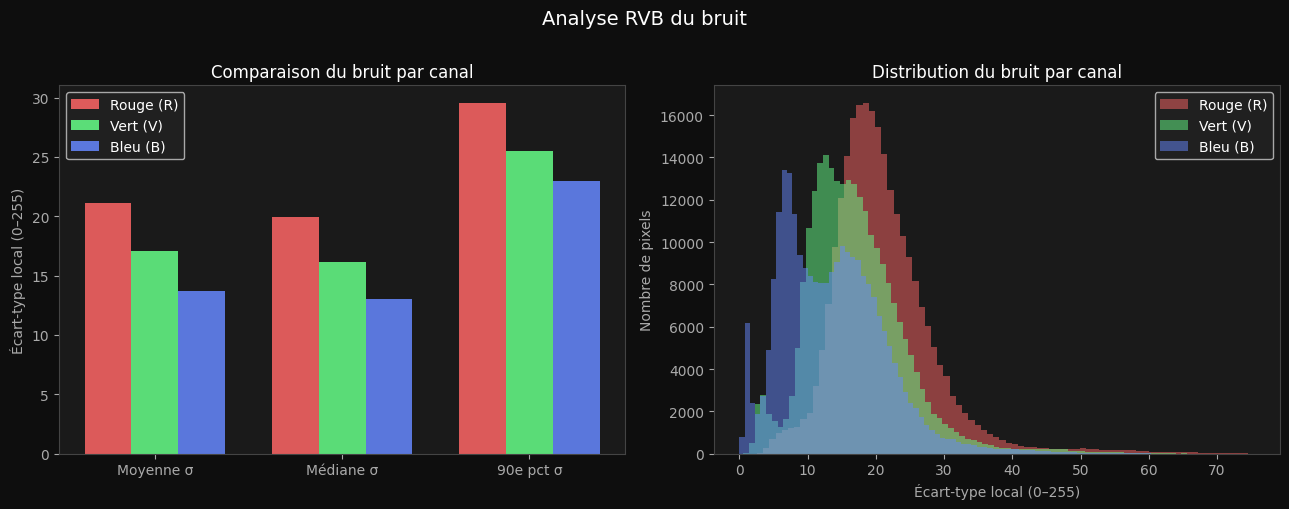

In [10]:
noms_canaux  = ['Rouge (R)', 'Vert (V)', 'Bleu (B)']
couleurs_bar = ['#ff6666',   '#66ff88',  '#6688ff']

stats_canaux = []
for c in range(3):
    v = variance_locale(arr[:,:,c], TAILLE_FENETRE)
    s = np.sqrt(v[masque])
    stats_canaux.append({
        'nom':    noms_canaux[c],
        'moyenne': s.mean(),
        'mediane': np.median(s),
        'p90':     np.percentile(s, 90),
    })
    print(f"{noms_canaux[c]:12s}  σ moyen={s.mean():.2f}  médiane={np.median(s):.2f}  90e pct={np.percentile(s,90):.2f}")

# Graphique comparatif
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0e0e0e')

# Barres
cats   = ['Moyenne σ', 'Médiane σ', '90e pct σ']
x      = np.arange(len(cats))
largeur = 0.25
for i, (stat, coul) in enumerate(zip(stats_canaux, couleurs_bar)):
    vals = [stat['moyenne'], stat['mediane'], stat['p90']]
    axes[0].bar(x + i * largeur, vals, largeur, label=stat['nom'], color=coul, alpha=0.85)
axes[0].set_xticks(x + largeur)
axes[0].set_xticklabels(cats)
axes[0].set_ylabel("Écart-type local (0–255)")
axes[0].set_title("Comparaison du bruit par canal", color='white', fontsize=12)
axes[0].legend(facecolor='#222', labelcolor='white')

# Histogrammes superposés
for c, (nom, coul) in enumerate(zip(noms_canaux, couleurs_bar)):
    v = np.sqrt(variance_locale(arr[:,:,c], TAILLE_FENETRE)[masque])
    axes[1].hist(v, bins=80, color=coul, alpha=0.5, label=nom, edgecolor='none')
axes[1].set_title("Distribution du bruit par canal", color='white', fontsize=12)
axes[1].set_xlabel("Écart-type local (0–255)")
axes[1].set_ylabel("Nombre de pixels")
axes[1].legend(facecolor='#222', labelcolor='white')

plt.suptitle("Analyse RVB du bruit", color='white', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 8. Tableau récapitulatif final

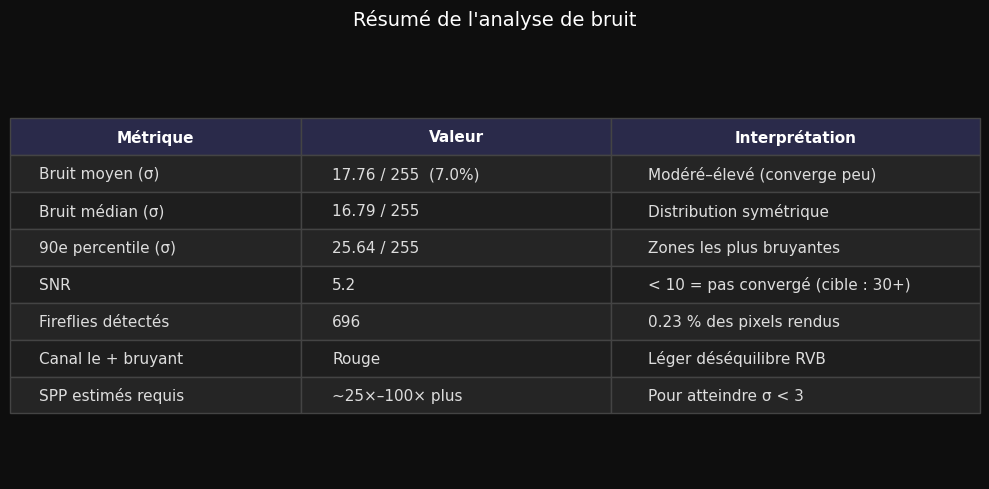


✅ Analyse complète terminée.


In [11]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#0e0e0e')
ax.set_facecolor('#0e0e0e')
ax.axis('off')

entetes = ['Métrique', 'Valeur', 'Interprétation']
donnees = [
    ['Bruit moyen (σ)',      f'{bruit_hair.mean():.2f} / 255  ({100*bruit_hair.mean()/255:.1f}%)', 'Modéré–élevé (converge peu)'],
    ['Bruit médian (σ)',     f'{np.median(bruit_hair):.2f} / 255',                                 'Distribution symétrique'],
    ['90e percentile (σ)',   f'{np.percentile(bruit_hair,90):.2f} / 255',                          'Zones les plus bruyantes'],
    ['SNR',                  f'{snr:.1f}',                                                          '< 10 = pas convergé (cible : 30+)'],
    ['Fireflies détectés',   f'{fireflies.sum()}',                                                  '0.23 % des pixels rendus'],
    ['Canal le + bruyant',   'Rouge',                                                               'Léger déséquilibre RVB'],
    ['SPP estimés requis',   '~25×–100× plus',                                                      'Pour atteindre σ < 3'],
]

table = ax.table(
    cellText=donnees,
    colLabels=entetes,
    cellLoc='left',
    loc='center',
    colWidths=[0.3, 0.32, 0.38],
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.0)

# Mise en forme
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#444444')
    if row == 0:
        cell.set_facecolor('#2a2a4a')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#1e1e1e')
        cell.set_text_props(color='#dddddd')
    else:
        cell.set_facecolor('#252525')
        cell.set_text_props(color='#dddddd')

ax.set_title("Résumé de l'analyse de bruit", color='white', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("\n✅ Analyse complète terminée.")


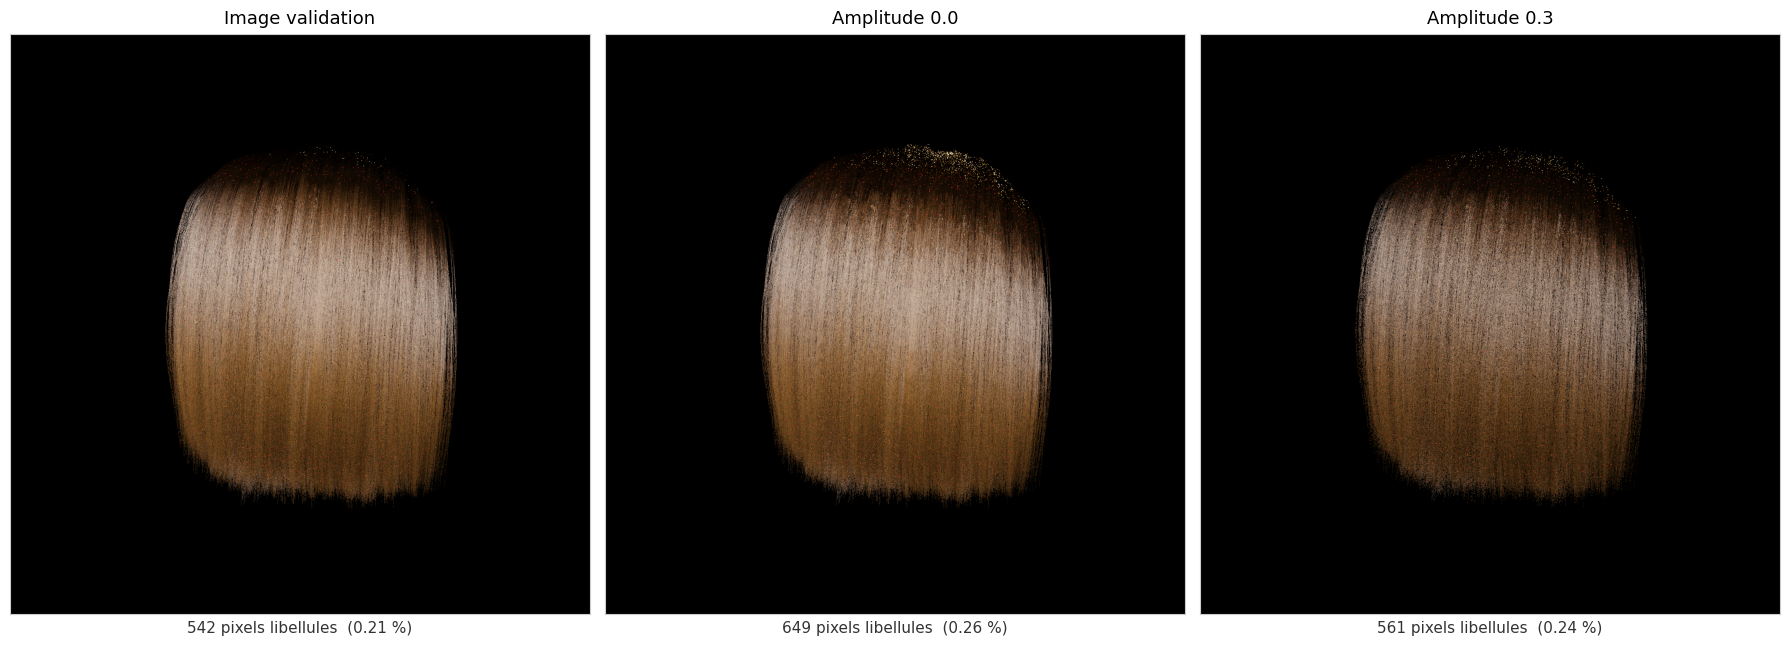

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import uniform_filter
from pathlib import Path

SEUIL_FOND  = 8
SEUIL_Z     = 4.0
TAILLE_WIN  = 11

def detecter_libellules(arr):
    lum    = arr.mean(axis=2)
    masque = lum > SEUIL_FOND

    lum_fill  = np.where(masque, lum,    0.0)
    lum2_fill = np.where(masque, lum**2, 0.0)
    cnt       = uniform_filter(masque.astype(np.float64), size=TAILLE_WIN)
    cnt_safe  = np.maximum(cnt, 1e-8)

    moy     = uniform_filter(lum_fill,  size=TAILLE_WIN) / cnt_safe
    moy2    = uniform_filter(lum2_fill, size=TAILLE_WIN) / cnt_safe
    var     = np.clip(moy2 - moy**2, 0, None)
    std_loc = np.sqrt(var)

    z = np.where(masque & (std_loc > 1),
                 (lum - moy) / np.maximum(std_loc, 1e-8),
                 0.0)

    return (z > SEUIL_Z) & masque, masque

sweep_dir = next(Path('.').glob('amplitude_sweep_*'))

images = {
    'Image validation': np.array(Image.open('profile16spp1000.png').convert('RGB'), dtype=np.uint8),
    'Amplitude 0.0':    np.array(Image.open(sweep_dir / 'profile_gpis_amp_0_0.png').convert('RGB'), dtype=np.uint8),
    'Amplitude 0.3':    np.array(Image.open(sweep_dir / 'profile_gpis_amp_0_3.png').convert('RGB'), dtype=np.uint8),
}

# ── Figure 1 : libellules en rouge ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7), facecolor='white')
fig.patch.set_facecolor('white')

for ax, (titre, arr) in zip(axes, images.items()):
    libellules, masque = detecter_libellules(arr.astype(np.float64))
    n   = int(libellules.sum())
    pct = 100 * n / max(int(masque.sum()), 1)

    vis = arr.copy()
    vis[libellules] = [255, 40, 40]
    ax.imshow(vis)
    ax.set_title(titre, fontsize=13, color='black', pad=8)
    ax.set_xlabel(f"{n:,} pixels libellules  ({pct:.2f} %)", fontsize=11, color='#333333')
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_color('#cccccc')

plt.tight_layout()
plt.show()

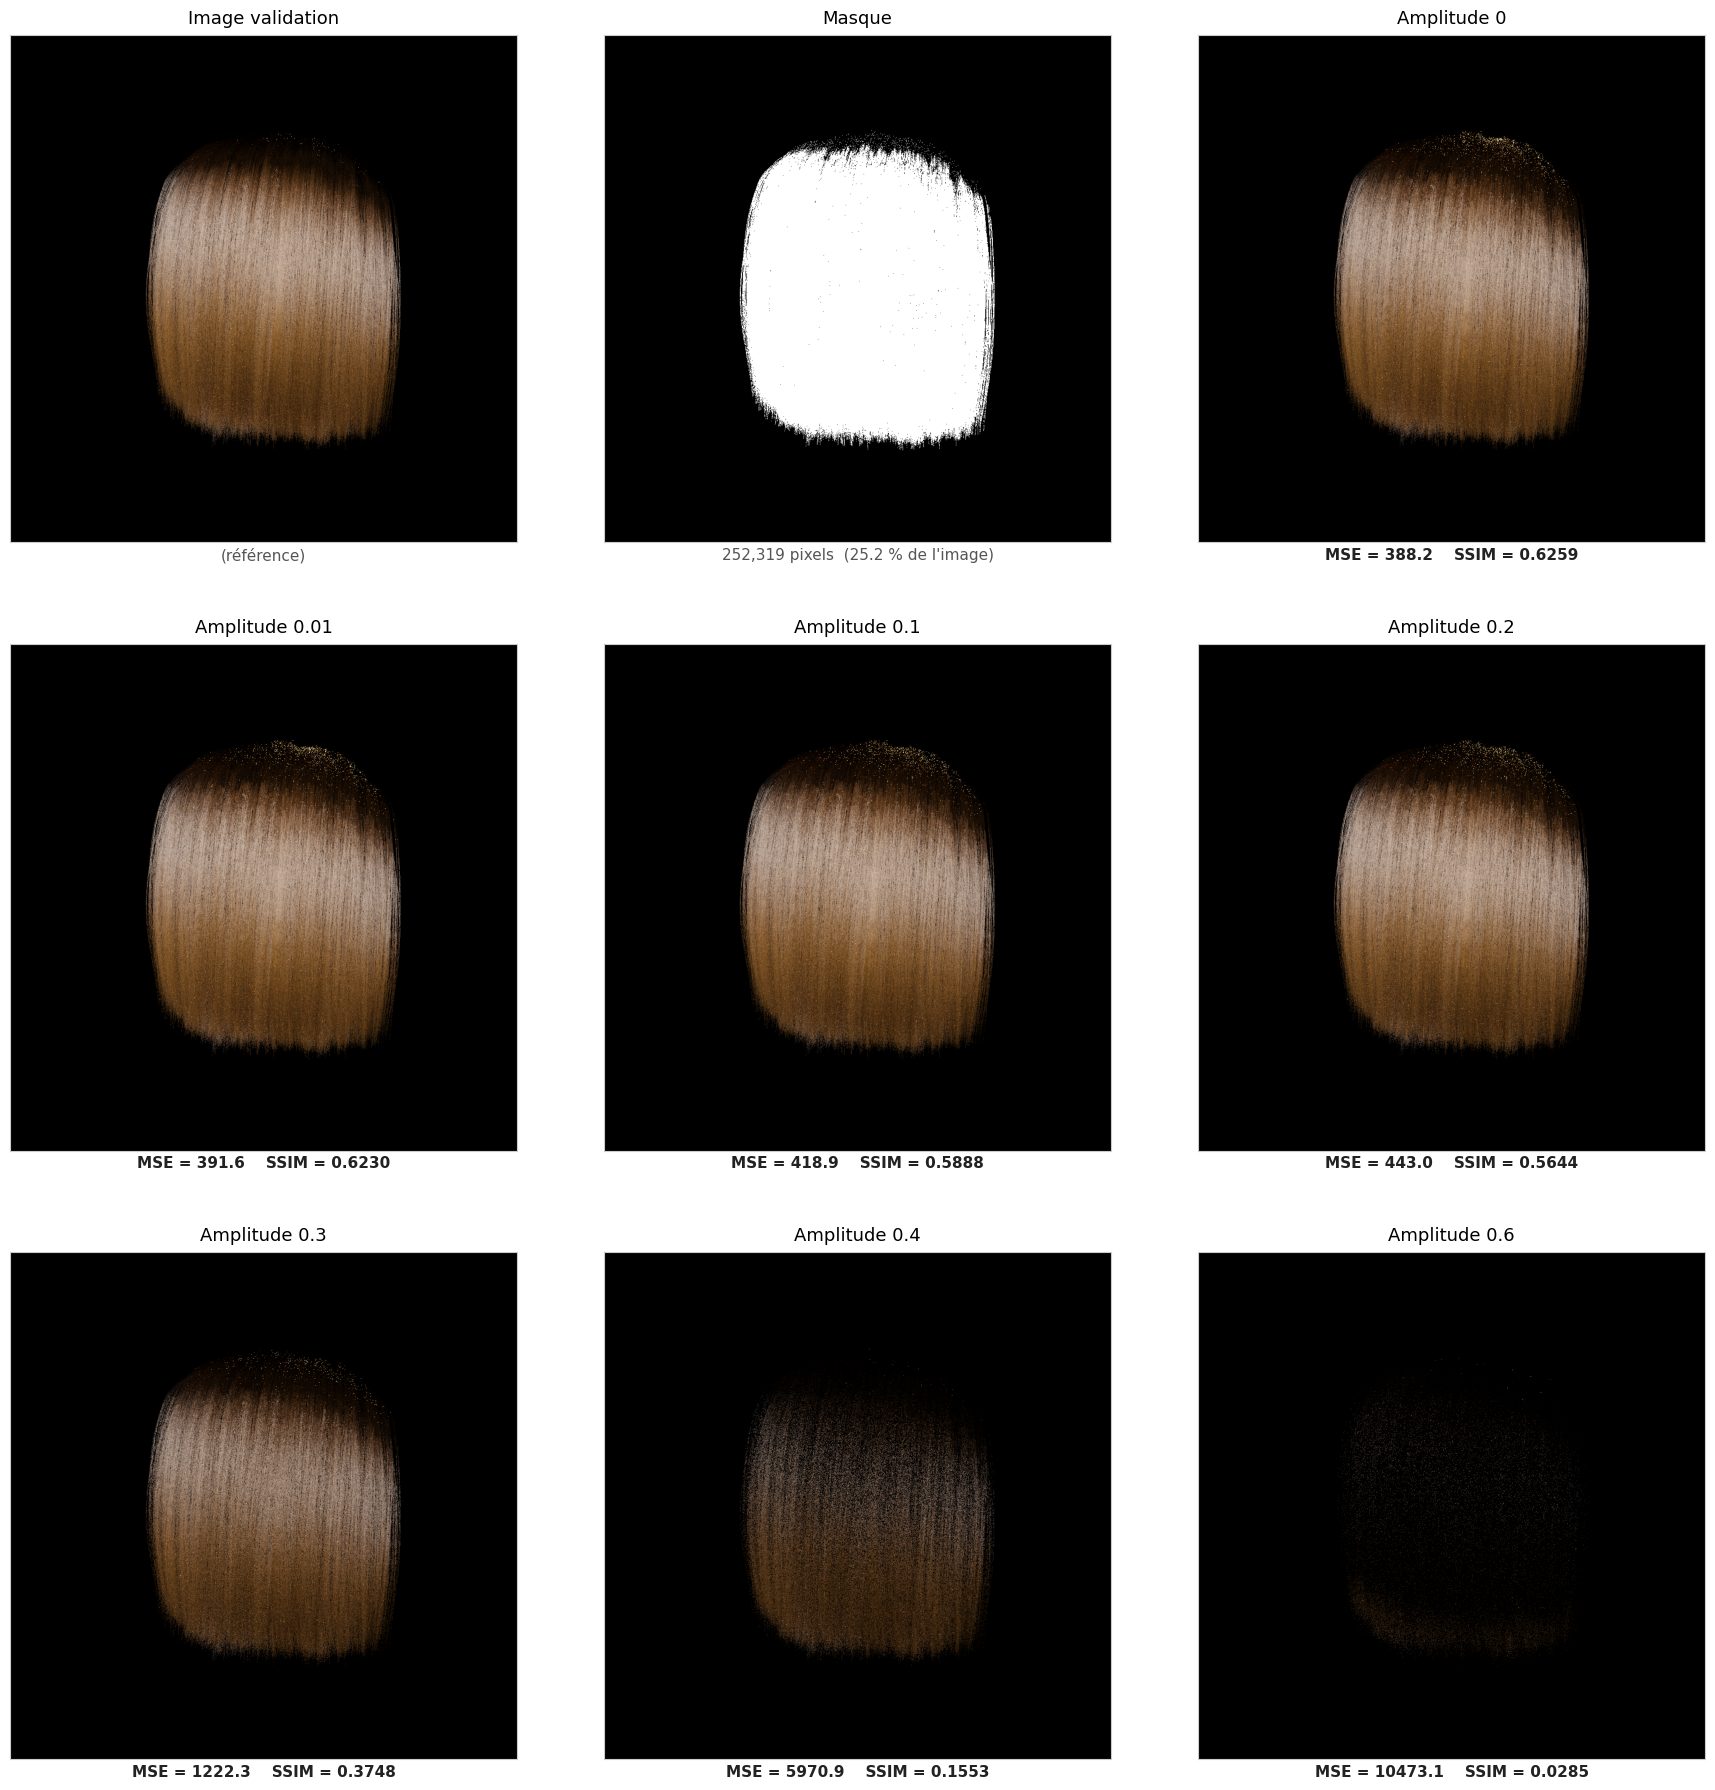

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from skimage.metrics import structural_similarity as ssim

SEUIL_FOND = 8

renders_dir = Path('gpis-renders')
fichiers    = sorted(renders_dir.glob('profile_gpis_amp_*.png'))
amplitudes  = [float(p.stem.replace('profile_gpis_amp_', '').replace('_', '.'))
               for p in fichiers]

ref        = np.array(Image.open('profile16spp1000.png').convert('RGB'), dtype=np.float32)
masque_ref = ref.mean(axis=2) > SEUIL_FOND

sweeps = [(amp, np.array(Image.open(f).convert('RGB'), dtype=np.float32))
          for amp, f in zip(amplitudes, fichiers)]

def metriques_masquees(ref, img, masque):
    mse = float(np.mean((ref[masque] - img[masque]) ** 2))
    _, ssim_map = ssim(ref / 255.0, img / 255.0,
                       data_range=1.0, channel_axis=2, full=True)
    ssim_m = float(ssim_map[masque].mean())
    return mse, ssim_m

def style_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_color('#cccccc')

# ── Figure 2 : grille 3×3 — référence | masque | 7 renders ──────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 18), facecolor='white')
fig.patch.set_facecolor('white')

# (0,0) Image de validation
ax = axes[0, 0]
ax.imshow(ref.astype(np.uint8))
ax.set_title("Image validation", fontsize=13, color='black', pad=8)
ax.set_xlabel("(référence)", fontsize=11, color='#555555')
style_ax(ax)

# (0,1) Masque
ax = axes[0, 1]
ax.imshow(masque_ref, cmap='gray')
ax.set_title("Masque", fontsize=13, color='black', pad=8)
n_masque   = int(masque_ref.sum())
pct_masque = 100 * n_masque / masque_ref.size
ax.set_xlabel(f"{n_masque:,} pixels  ({pct_masque:.1f} % de l'image)", fontsize=11, color='#555555')
style_ax(ax)

# (0,2) puis (1,0)…(2,2) : 7 renders
render_cells = [(0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]
for (row, col), (amp, img) in zip(render_cells, sweeps):
    ax = axes[row, col]
    mse, ssim_m = metriques_masquees(ref, img, masque_ref)
    ax.imshow(img.astype(np.uint8))
    ax.set_title(f"Amplitude {amp:g}", fontsize=13, color='black', pad=8)
    ax.set_xlabel(f"MSE = {mse:.1f}    SSIM = {ssim_m:.4f}",
                  fontsize=11, color='#222222', fontweight='bold')
    style_ax(ax)

plt.tight_layout(h_pad=4.0)
plt.show()

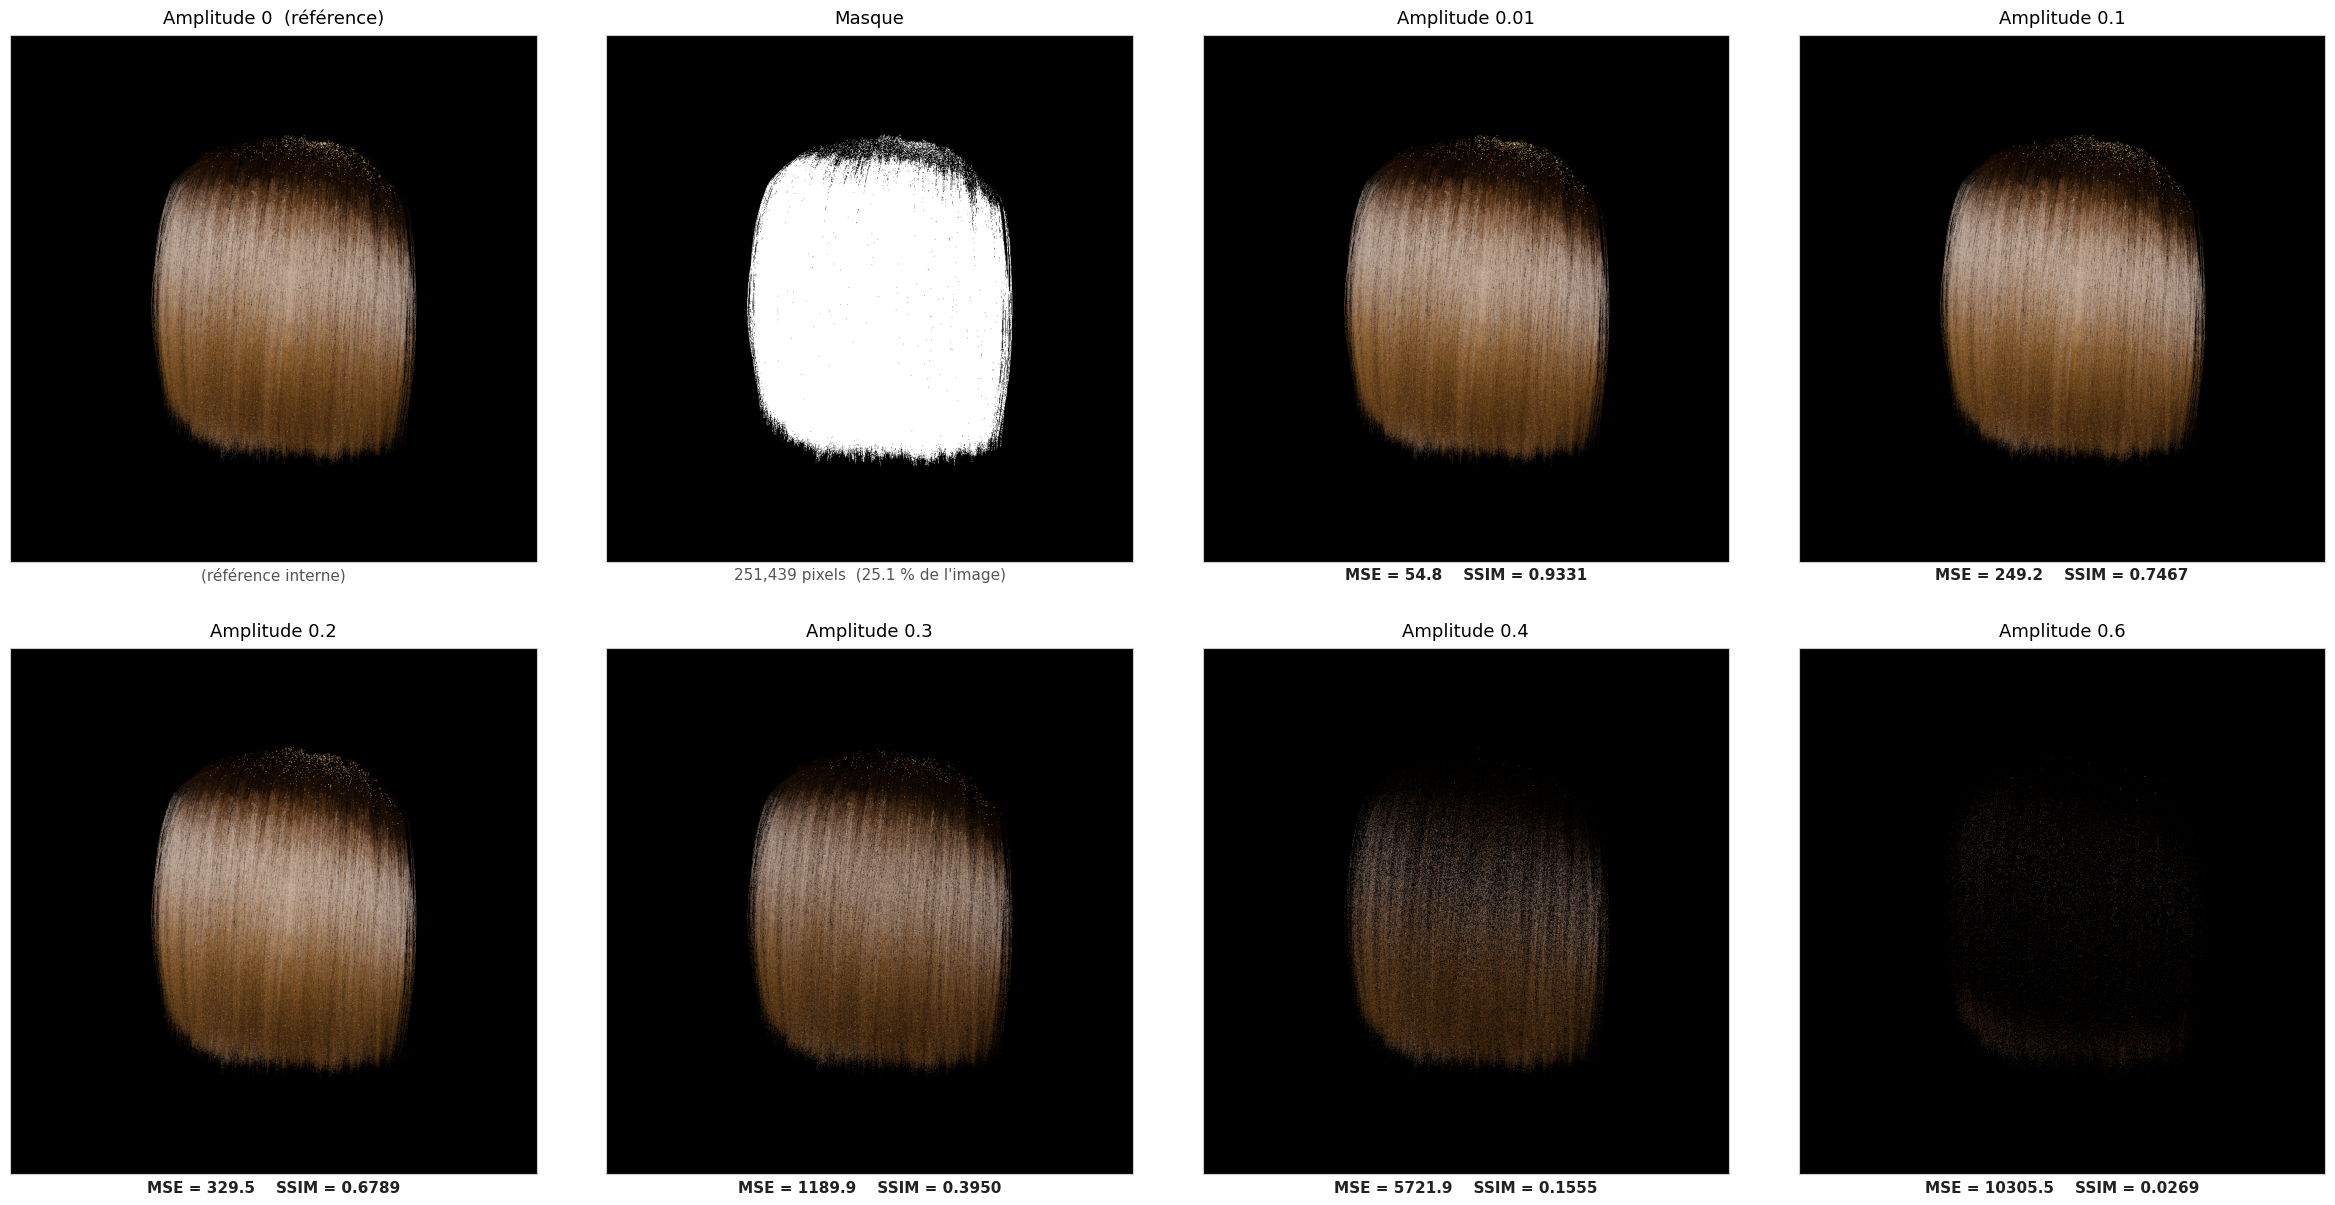

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from skimage.metrics import structural_similarity as ssim

SEUIL_FOND = 8

renders_dir = Path('gpis-renders')
fichiers    = sorted(renders_dir.glob('profile_gpis_amp_*.png'))
amplitudes  = [float(p.stem.replace('profile_gpis_amp_', '').replace('_', '.'))
               for p in fichiers]

# Référence = amplitude 0.0
ref_amp0    = np.array(Image.open(renders_dir / 'profile_gpis_amp_0_0.png').convert('RGB'), dtype=np.float32)
masque_amp0 = ref_amp0.mean(axis=2) > SEUIL_FOND

# Sweeps = tous sauf amplitude 0.0
sweeps_autres = [(amp, np.array(Image.open(f).convert('RGB'), dtype=np.float32))
                 for amp, f in zip(amplitudes, fichiers) if amp != 0.0]

def metriques_masquees(ref, img, masque):
    mse = float(np.mean((ref[masque] - img[masque]) ** 2))
    _, ssim_map = ssim(ref / 255.0, img / 255.0,
                       data_range=1.0, channel_axis=2, full=True)
    ssim_m = float(ssim_map[masque].mean())
    return mse, ssim_m

def style_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_color('#cccccc')

# ── Figure 3 : grille 2×4 — référence amp 0.0 | masque | 6 renders ──────────
fig, axes = plt.subplots(2, 4, figsize=(24, 12), facecolor='white')
fig.patch.set_facecolor('white')

# (0,0) Référence amplitude 0.0
ax = axes[0, 0]
ax.imshow(ref_amp0.astype(np.uint8))
ax.set_title("Amplitude 0  (référence)", fontsize=13, color='black', pad=8)
ax.set_xlabel("(référence interne)", fontsize=11, color='#555555')
style_ax(ax)

# (0,1) Masque
ax = axes[0, 1]
ax.imshow(masque_amp0, cmap='gray')
ax.set_title("Masque", fontsize=13, color='black', pad=8)
n_masque   = int(masque_amp0.sum())
pct_masque = 100 * n_masque / masque_amp0.size
ax.set_xlabel(f"{n_masque:,} pixels  ({pct_masque:.1f} % de l'image)", fontsize=11, color='#555555')
style_ax(ax)

# (0,2)…(1,3) : 6 renders
render_cells = [(0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3)]
for (row, col), (amp, img) in zip(render_cells, sweeps_autres):
    ax = axes[row, col]
    mse, ssim_m = metriques_masquees(ref_amp0, img, masque_amp0)
    ax.imshow(img.astype(np.uint8))
    ax.set_title(f"Amplitude {amp:g}", fontsize=13, color='black', pad=8)
    ax.set_xlabel(f"MSE = {mse:.1f}    SSIM = {ssim_m:.4f}",
                  fontsize=11, color='#222222', fontweight='bold')
    style_ax(ax)

plt.tight_layout(h_pad=4.0)
plt.show()